# Impacto da Degradação de Manguezais após o rompimento da Barragem de Mariana sobre a Pesca Artesanal no Litoral do Espírito Santo
**Projeto Integrador III | GABRIELY BARBOSA DA SILVA AZEVEDO | GUILHERME DOS SANTOS GONÇALVES BISPO**

---
## Contexto e Motivação

### O problema que motivou este projeto

O Espírito Santo possui 411 km de litoral e uma das comunidades de pescadores artesanais
mais antigas e ativas do Brasil. Dezenas de colônias de pesca distribuídas ao longo da
costa dependem diretamente da saúde dos ecossistemas costeiros, em especial dos
manguezais, para garantir sua subsistência.

Os manguezais são florestas costeiras que crescem na interface entre a terra e o mar,
em regiões de água salobra. Eles funcionam como berçário natural para inúmeras espécies
marinhas: o camarão-sete-barbas, o robalo e o caranguejo-uçá passam fases críticas do
seu ciclo de vida dentro desse ecossistema. Sem manguezal saudável, os estoques dessas
espécies diminuem, e com eles, a renda e a segurança alimentar das famílias que pescam.

Em novembro de 2015, o rompimento da barragem de Fundão em Mariana (MG), operada pela
Samarco, lançou aproximadamente 40 milhões de m³ de rejeitos de mineração no Rio Doce.
A lama percorreu mais de 600 km até atingir o oceano Atlântico pela foz do Rio Doce,
no litoral norte capixaba, contaminando estuários, manguezais e áreas de pesca
artesanal que ainda sentem os efeitos quase uma década depois.

---

### O que este projeto faz

Pescadores artesanais do litoral capixaba relatam há anos uma redução progressiva nas
capturas. Mas relato, sozinho, não vira base técnica. Sem um número que comprove e dimensione o
impacto, gestores públicos, órgãos ambientais e o sistema judiciário não dispõem de
base técnica para agir.

Este projeto constrói essa evidência quantitativa. Integramos quatro fontes de dados
públicas e científicas para responder a uma pergunta central:

> *A degradação dos manguezais do Espírito Santo, acelerada pelo desastre de Mariana
> em 2015, está associada à queda documentada na produção pesqueira artesanal?*

Para responder, aplicamos análise exploratória de dados, modelos de regressão linear,
segmentada, polinomial e regressão múltipla (OLS) sobre séries históricas que cobrem
de 1985 a 2023.

---

### Por que isso importa além da academia

Os resultados deste projeto têm três destinatários práticos:

Pescadores e comunidades costeiras: Que precisam de evidência quantitativa para
embasar pedidos de indenização e políticas de compensação junto à Fundação Renova e
ao sistema judiciário.

Gestores públicos: SEAMA-ES, IBAMA e Ministério da Pesca, que precisam de dados
para priorizar ações de restauração de manguezal e definir zonas de proteção estuarina.

A sociedade: Que raramente vê traduzido em números o custo humano de desastres
ambientais.

---

### Como este notebook está organizado

| Seção | Conteúdo |
|---|---|
| 1. Configuração | Importação de bibliotecas e definição de variáveis globais |
| 2. Dados | Carregamento e limpeza das quatro fontes utilizadas |
| 3. Análise Exploratória | Visualizações das séries temporais e padrões identificados |
| 4. Modelagem | Modelos de regressão aplicados e resultados estatísticos |
| 5. Insights e Limitações | Principais achados e transparência metodológica |
| 6. Exportação | Geração dos arquivos de dados processados e figuras |

---

### Fontes de dados utilizadas

| Fonte | O que fornece | Período |
|---|---|---|
| **MapBiomas Coleção 9** | Cobertura de manguezal em hectares por ano - ES | 1985-2023 |
| **Sea Around Us** (Pauly & Zeller, 2016) | Capturas pesqueiras reconstruídas por espécie - ES | 2000-2015 |
| **PMAP-ES / UFES** | Desembarques pesqueiros artesanais reportados - ES | 2021-2023 |
| **Boletim Estatístico UFES/MPA** | Referência de captura por espécie e município - ES | 2011 |

> **Nota sobre a lacuna 2016-2020:** não existem dados oficiais de estatística pesqueira
> do ES para esse período. Essa ausência é reconhecida pela literatura científica
> (Musiello-Fernandes et al., 2020; Braga et al., 2021) e representa uma limitação
> estrutural do monitoramento pesqueiro brasileiro, não uma falha deste projeto.

## 1. Configuração e Importação de Bibliotecas

 - pandas: manipulação de dados tabulares (DataFrames)
 - numpy: operações matemáticas e arrays
 - matplotlib/seaborn: visualização de dados
 - sklearn: modelos de machine learning (regressão linear, polinomial, pipelines)
 - statsmodels: regressão múltipla com sumário estatístico completo (OLS)
 - MARIANA = 2015: variável global que marca o ano do desastre,
   usada como ponto de quebra estrutural em todos os modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (13, 5)

CORES = {
    'sau':      '#1565C0',
    'pmap':     '#E53935',
    'manguezal':'#795548',
    'pre':      '#90CAF9',
    'pos':      '#EF9A9A',
    'destaque': '#FF5722',
    'verde':    '#43A047'
}
MARIANA = 2015


## 2. Carregamento e Preparação dos Dados

-  Sea Around Us é uma base de reconstrução de capturas pesqueiras globais
    (Pauly & Zeller, 2016 Nature Communications).
    Usamos **str.contains()** para buscar as espécies pelo nome em português,
    pois o mesmo nome pode ter variações de grafia no dataset.
    **groupby('Year').sum()** agrega todas as modalidades de pesca por ano.
    Recortamos a partir de 2000 para manter consistência temporal com
    as demais fontes e evitar distorções de dados muito antigos.

-  O CSV do PMAP-ES usa formatação brasileira (ponto como separador de milhar,
    vírgula como decimal), por isso aplicamos str.replace antes de converter para float.
    encoding='latin1' resolve caracteres especiais do português (ã, ç, é...).
    Dividimos kg por 1000 para padronizar todas as séries em toneladas.

-  Combinamos as duas fontes (Sea Around Us e PMAP-ES) em um único DataFrame
    usando **pd.concat()**, mantendo a coluna 'fonte' para rastrear a origem
    de cada ponto nas visualizações e na interpretação dos modelos.
    **A lacuna 2016-2020 é intencional: não existem dados oficiais disponíveis
    para esse período (confirmado por Musiello-Fernandes et al., 2020;
    Braga et al., 2021).**

-  O MapBiomas classifica a cobertura do solo por pixel de satélite anualmente.
    Filtramos **state_acronym == 'ES'** e **class_level_2 == '1.3. Mangrove'**
    para isolar apenas a cobertura de manguezal no Espírito Santo.
    **.sum()** agrega os pixels de todas as unidades territoriais do estado,
    resultando na área total de manguezal em hectares por ano.

In [2]:
# 2.1 Sea Around Us - série histórica ES (1950-2015)
df_sau = pd.read_excel('data/cobertura2009-2015.xlsx')

# Filtrar espécies
cam_sau = (df_sau[df_sau['PortugueseCommonName']
           .str.contains('amarão sete', case=False, na=False)]
           .groupby('Year')['CatchAmount_t'].sum())

rob_sau = (df_sau[df_sau['PortugueseCommonName']
           .str.contains('obalo', case=False, na=False)]
           .groupby('Year')['CatchAmount_t'].sum())

car_sau = (df_sau[df_sau['PortugueseCommonName'] == 'Caranguejo']
           .groupby('Year')['CatchAmount_t'].sum())

# Recorte 2000-2015
cam_sau = cam_sau[cam_sau.index >= 2000]
rob_sau = rob_sau[rob_sau.index >= 2000]
car_sau = car_sau[car_sau.index >= 2000]

print('Sea Around Us carregado.')
print(f'  Camarão-sete-barbas: {len(cam_sau)} anos | max {cam_sau.max():.0f}t em {cam_sau.idxmax()}')
print(f'  Robalo: {len(rob_sau)} anos | max {rob_sau.max():.2f}t em {rob_sau.idxmax()}')
print(f'  Caranguejo: {len(car_sau)} anos')

Sea Around Us carregado.
  Camarão-sete-barbas: 16 anos | max 2752t em 2011
  Robalo: 16 anos | max 9.00t em 2005
  Caranguejo: 16 anos


In [3]:
# 2.2 PMAP-ES (2021-2023)
df_pmap_raw = pd.read_csv('data/relatorio-pesca.csv', encoding='latin1', sep=None, engine='python')
df_pmap_raw['kg'] = (df_pmap_raw['kg no Período']
                     .str.replace('.', '', regex=False)
                     .str.replace(',', '.', regex=False)
                     .astype(float))
df_pmap = df_pmap_raw[['Ano','Mês','Município','Pescado','kg']].copy()
df_pmap.columns = ['ano','mes','municipio','especie','kg']

# Totais anuais por espécie (convertendo kg para toneladas)
pmap_anual = df_pmap.groupby(['ano','especie'])['kg'].sum().reset_index()
pmap_anual['ton'] = pmap_anual['kg'] / 1000

cam_pmap = pmap_anual[pmap_anual['especie']=='Camarão-sete-barbas'].set_index('ano')['ton']
rob_pmap = pmap_anual[pmap_anual['especie']=='Robalos'].set_index('ano')['ton']

print('PMAP-ES carregado.')
print('Camarão (ton/ano):')
print(cam_pmap.to_string())
print('Robalo (ton/ano):')
print(rob_pmap.to_string())

PMAP-ES carregado.
Camarão (ton/ano):
ano
2021    388.56125
2022    418.41070
2023    375.16390
Robalo (ton/ano):
ano
2021    1.24030
2022    0.51085
2023    0.21102


In [4]:
# 2.3 Séries combinadas
# Camarão: SAU (2000-2015) + PMAP-ES (2021-2023)
cam_serie = pd.concat([
    pd.DataFrame({'ano': cam_sau.index, 'ton': cam_sau.values, 'fonte': 'Sea Around Us'}),
    pd.DataFrame({'ano': cam_pmap.index, 'ton': cam_pmap.values, 'fonte': 'PMAP-ES'})
]).reset_index(drop=True)

# Robalo: SAU (2000-2015) + PMAP-ES (2021-2023)
rob_serie = pd.concat([
    pd.DataFrame({'ano': rob_sau.index, 'ton': rob_sau.values, 'fonte': 'Sea Around Us'}),
    pd.DataFrame({'ano': rob_pmap.index, 'ton': rob_pmap.values, 'fonte': 'PMAP-ES'})
]).reset_index(drop=True)

# Caranguejo: apenas SAU
car_serie = pd.DataFrame({'ano': car_sau.index, 'ton': car_sau.values, 'fonte': 'Sea Around Us'})

print('Séries combinadas:')
print(f'  Camarão: {len(cam_serie)} pontos | anos {cam_serie.ano.min()}-{cam_serie.ano.max()}')
print(f'  Robalo:  {len(rob_serie)} pontos | anos {rob_serie.ano.min()}-{rob_serie.ano.max()}')
print(f'  Caranguejo: {len(car_serie)} pontos | anos {car_serie.ano.min()}-{car_serie.ano.max()}')

Séries combinadas:
  Camarão: 19 pontos | anos 2000-2023
  Robalo:  19 pontos | anos 2000-2023
  Caranguejo: 16 pontos | anos 2000-2015


In [5]:
# 2.4 MapBiomas - manguezal ES (1985-2023)
df_mb = pd.read_excel('data/mapBiomas-coberturaManguezal.xlsx')
es_mang = df_mb[(df_mb['state_acronym'] == 'ES') &
                (df_mb['class_level_2'] == '1.3. Mangrove')]
anos_cols = [c for c in df_mb.columns if str(c).replace('.0','').isdigit()]
serie_mang = es_mang[anos_cols].sum()
df_mang = pd.DataFrame({
    'ano': [int(float(a)) for a in serie_mang.index],
    'area_ha': serie_mang.values
})
df_mang = df_mang[df_mang['ano'] <= 2023].copy()

print(f'Manguezal ES: {df_mang.ano.min()}-{df_mang.ano.max()} | '
      f'Pico: {df_mang.area_ha.max():.0f} ha em {df_mang.loc[df_mang.area_ha.idxmax(),"ano"]}')
print(f'Área 2015: {df_mang[df_mang.ano==2015].area_ha.values[0]:.0f} ha')
print(f'Área 2023: {df_mang[df_mang.ano==2023].area_ha.values[0]:.0f} ha')

Manguezal ES: 1985-2023 | Pico: 5286 ha em 2014
Área 2015: 5272 ha
Área 2023: 4999 ha


## 3. Análise Exploratória

-  Série temporal completa do manguezal (1985-2023).
    axvline marca 2015 como referência visual do desastre de Mariana.
    fill_betweenx destaca o período pós-Mariana em vermelho translúcido.
    As anotações indicam o pico histórico e a queda abrupta de 2016-2017,
    que coincide com os anos imediatamente após o desastre.

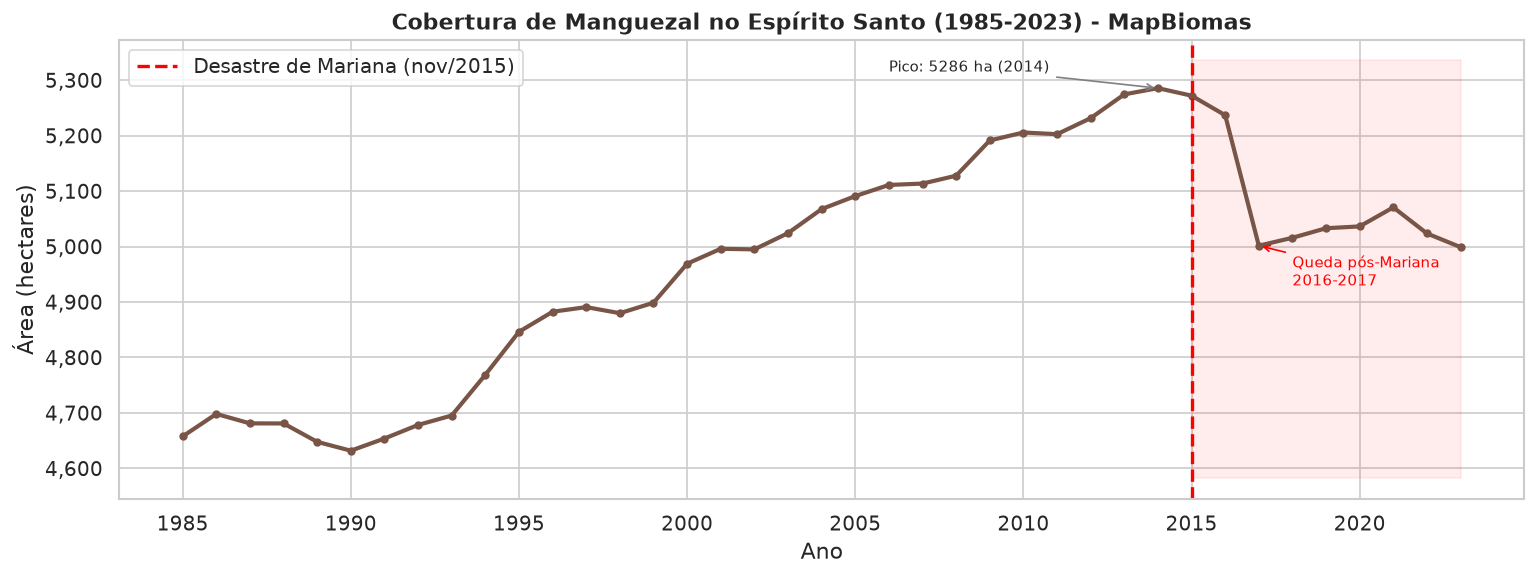

In [6]:
# 3.1 Série temporal manguezal ES
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_mang.ano, df_mang.area_ha, color=CORES['manguezal'], lw=2.5, marker='o', ms=4)
ax.axvline(MARIANA, color='red', lw=2, ls='--', label='Desastre de Mariana (nov/2015)')
ax.fill_betweenx([df_mang.area_ha.min()-50, df_mang.area_ha.max()+50],
                 MARIANA, 2023, alpha=0.07, color='red')
pico_ha = df_mang.area_ha.max()
pico_ano = df_mang.loc[df_mang.area_ha.idxmax(),'ano']
ax.annotate(f'Pico: {pico_ha:.0f} ha ({pico_ano})',
            xy=(pico_ano, pico_ha), xytext=(2006, pico_ha+30),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.annotate('Queda pós-Mariana\n2016-2017',
            xy=(2017, df_mang[df_mang.ano==2017].area_ha.values[0]),
            xytext=(2018, 4930), arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')
ax.set_title('Cobertura de Manguezal no Espírito Santo (1985-2023) - MapBiomas', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Área (hectares)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('graficos_gerados/fig01_manguezal_serie.png', bbox_inches='tight')
plt.show()

## Leitura do gráfico
A série cresce de forma quase contínua entre 1985 e 2014, de ~4.657 ha para o pico de 5.286 ha. Esse avanço é compatível com a recuperação natural de manguezais sob pressão antrópica moderada descrita por Musiello-Fernandes et al. (2020). A partir de 2015 (linha vermelha, Mariana) a curva muda: entre 2015 e 2017 a área cai de ~5.272 ha para ~5.001 ha, cerca de 271 ha em dois anos, e depois se estabiliza em torno de 5.000-5.070 ha, sem voltar ao patamar anterior.

Isso importa direto para a hipótese do trabalho: perder área de manguezal reduz o habitat de berçário de espécies estuarino-dependentes como o camarão-sete-barbas e o robalo (Braga et al., 2021).

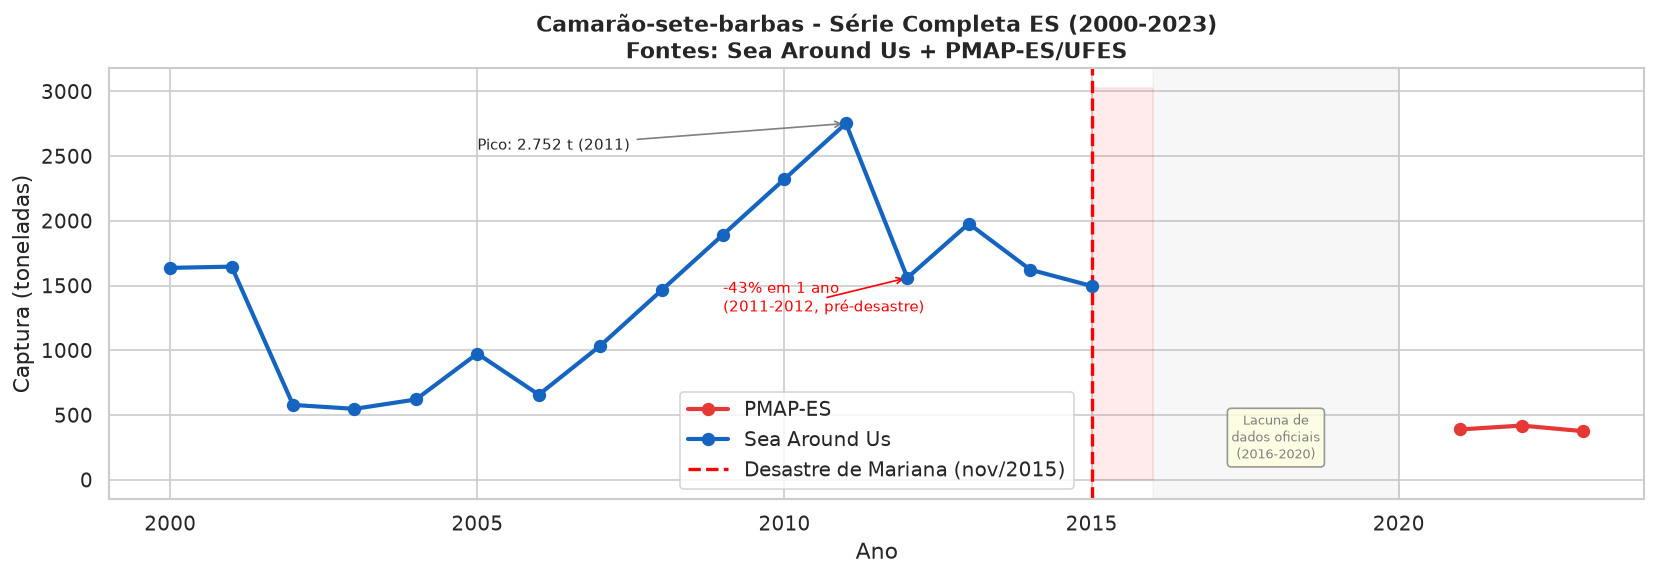

Queda pico (2011: 2752t) - 2023 (375t): -86.4%
Queda 2011-2012 (pré-desastre): -43.3%


In [7]:
# 3.2 Série completa camarão-sete-barbas (2000-2023) 

# Plotamos as duas fontes com cores distintas para deixar explícita
# a descontinuidade metodológica entre SAU (reconstruído) e PMAP-ES (reportado).
# axvspan cinza destaca visualmente a lacuna 2016-2020.
# A anotação da queda de -43% em 2011-2012 é o principal achado:
# marca o início do declínio, ainda no período pré-desastre (a barragem rompeu em nov/2015).

fig, ax = plt.subplots(figsize=(14, 5))

for fonte, grp in cam_serie.groupby('fonte'):
    cor = CORES['sau'] if fonte == 'Sea Around Us' else CORES['pmap']
    ax.plot(grp.ano, grp.ton, 'o-', color=cor, lw=2.5, ms=7, label=fonte, zorder=5)

ax.axvline(MARIANA, color='red', lw=2, ls='--', label='Desastre de Mariana (nov/2015)')
ax.fill_betweenx([0, cam_serie.ton.max()*1.1], MARIANA, 2016, alpha=0.08, color='red')
ax.axvspan(2016, 2020, alpha=0.06, color='gray')
ax.text(2018, cam_serie.ton.max()*0.06, 'Lacuna de\ndados oficiais\n(2016-2020)',
        ha='center', fontsize=8, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# Anotações
ax.annotate('Pico: 2.752 t (2011)',
            xy=(2011, 2752), xytext=(2005, 2550),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.annotate('-43% em 1 ano\n(2011-2012, pré-desastre)',
            xy=(2012, 1560), xytext=(2009, 1300),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

ax.set_title('Camarão-sete-barbas - Série Completa ES (2000-2023)\nFontes: Sea Around Us + PMAP-ES/UFES',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Captura (toneladas)')
ax.set_xlim(1999, 2024)
ax.legend()
plt.tight_layout()
plt.savefig('graficos_gerados/fig02_camarao_serie_completa.png', bbox_inches='tight')
plt.show()

pico = cam_serie.ton.max()
val_2023 = cam_serie[cam_serie.ano==2023].ton.values[0]
print(f'Queda pico (2011: {pico:.0f}t) - 2023 ({val_2023:.0f}t): {(val_2023/pico-1)*100:.1f}%')
print(f'Queda 2011-2012 (pré-desastre): {(1559.9/2752-1)*100:.1f}%')

## O que aparece
A série junta os dados reconstruídos do Sea Around Us (2000-2015, azul) com os reportados pelo PMAP-ES/UFES (2021-2023, vermelho). Dois pontos chamam atenção:

1. Crescimento até 2011: de ~578 t em 2002 ao pico de 2.752 t em 2011, com oscilações ainda altas até 2015 (~1.496 t).
2. Patamar bem mais baixo depois de 2015: os dados de 2021-2023 ficam entre 375 e 418 t, em torno de 15% do pico de 2011.

A queda de 43,3% de 2011 para 2012 acontece ainda antes de Mariana (nov/2015) e provavelmente reflete pressão de pesca e variabilidade do estoque, não o desastre. A mudança de patamar mesmo aparece entre 2015 e 2021-2023.

A lacuna 2016-2020 (em cinza) é estrutural: nenhuma fonte oficial de estatística pesqueira do ES cobre esses anos, o que é reconhecido na literatura (Musiello-Fernandes et al., 2020; Braga et al., 2021).

## Por que importa
A diferença entre mais de 2.700 t e menos de 400 t é grande demais para sair só de variação natural de estoque, e é coerente com o efeito combinado de degradação do manguezal, contaminação por rejeitos e piora da qualidade da água estuarina depois de novembro de 2015.

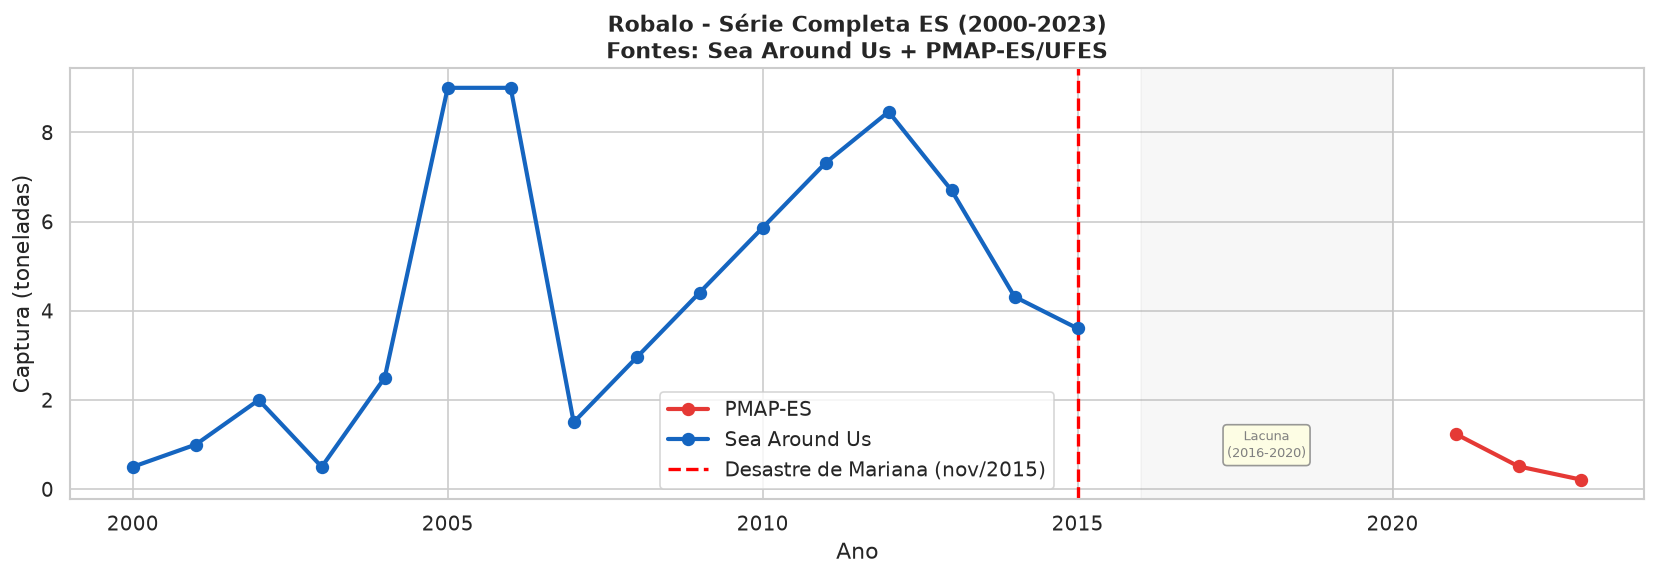

In [8]:
# 3.3 Série robalo (2000-2023)
fig, ax = plt.subplots(figsize=(14, 5))
for fonte, grp in rob_serie.groupby('fonte'):
    cor = CORES['sau'] if fonte == 'Sea Around Us' else CORES['pmap']
    ax.plot(grp.ano, grp.ton, 'o-', color=cor, lw=2.5, ms=7, label=fonte, zorder=5)
ax.axvline(MARIANA, color='red', lw=2, ls='--', label='Desastre de Mariana (nov/2015)')
ax.axvspan(2016, 2020, alpha=0.06, color='gray')
ax.text(2018, rob_serie.ton.max()*0.08, 'Lacuna\n(2016-2020)',
        ha='center', fontsize=8, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))
ax.set_title('Robalo - Série Completa ES (2000-2023)\nFontes: Sea Around Us + PMAP-ES/UFES',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Captura (toneladas)')
ax.set_xlim(1999, 2024)
ax.legend()
plt.tight_layout()
plt.savefig('graficos_gerados/fig03_robalo_serie_completa.png', bbox_inches='tight')
plt.show()

## Padrão observado
O robalo (Centropomus undecimalis e C. parallelus) depende do estuário-manguezal para reprodução e fase juvenil. Os volumes são bem menores que os do camarão (unidades de tonelada, não centenas), o que é esperado numa pesca artesanal costeira de pequena escala, e os dados do Sea Around Us têm cobertura reconhecidamente limitada para a espécie.

A série oscila, com máximos próximos de 9,0 t em 2005-2006 e de novo ~8,5 t em 2012, seguidos de queda até 2015 (~3,6 t) e continuação no PMAP-ES (2021: 1,24 t; 2022: 0,51 t; 2023: 0,21 t).

## O que isso indica
A queda do robalo preocupa por ser uma espécie-indicadora da saúde estuarina: diferente do camarão, ele depende da integridade do manguezal para fechar o ciclo de vida, o que reforça que o problema é de habitat, não só de esforço de pesca (Tonini et al., 2007, apud Braga et al., 2021).

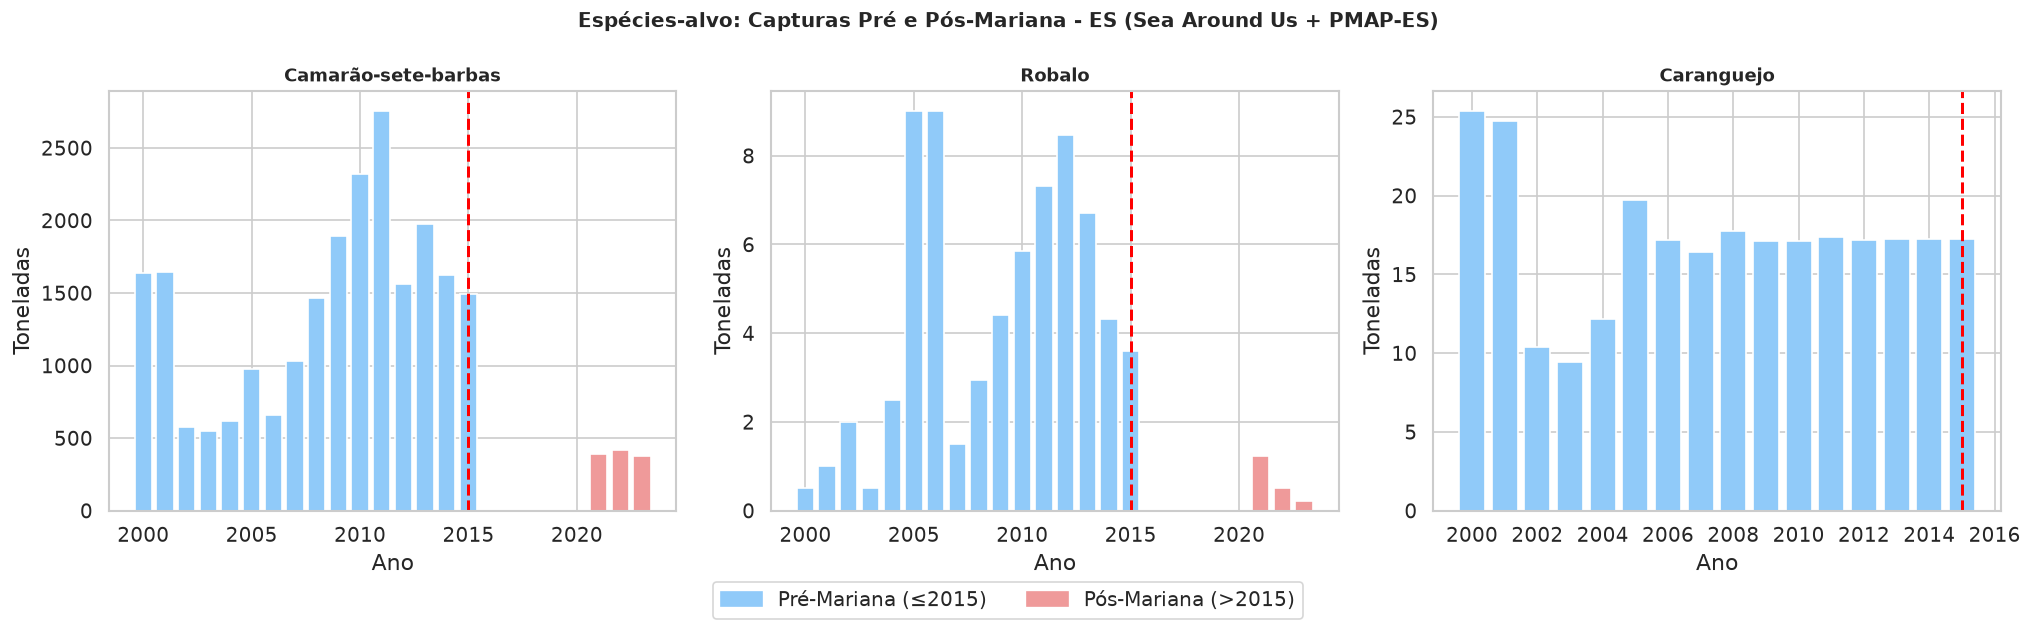

In [9]:
# 3.4 Três espécies - painel comparativo pré/pós 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, serie, titulo in zip(axes,
                              [cam_serie, rob_serie, car_serie],
                              ['Camarão-sete-barbas', 'Robalo', 'Caranguejo']):
    cores_barras = [CORES['pre'] if a <= MARIANA else CORES['pos'] for a in serie.ano]
    ax.bar(serie.ano, serie.ton, color=cores_barras, edgecolor='white', width=0.8)
    ax.axvline(MARIANA, color='red', lw=1.8, ls='--')
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Toneladas')
    ax.set_xlabel('Ano')

from matplotlib.patches import Patch
legenda = [Patch(color=CORES['pre'], label='Pré-Mariana (≤2015)'),
           Patch(color=CORES['pos'], label='Pós-Mariana (>2015)')]
fig.legend(handles=legenda, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Espécies-alvo: Capturas Pré e Pós-Mariana - ES (Sea Around Us + PMAP-ES)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos_gerados/fig04_tres_especies_painel.png', bbox_inches='tight')
plt.show()

## Comparando as três espécies
O painel põe as três espécies lado a lado: barras azuis para o período pré-Mariana, rosas para o pós.

- Camarão-sete-barbas: contraste forte, de até 2.752 t (pré) para menos de 420 t (pós), abaixo de um sexto do pico.
- Robalo: queda progressiva, com as barras pós-Mariana quase rente ao eixo zero frente a 2005-2012.
- Caranguejo: aqui é a categoria agregada "Caranguejo" do Sea Around Us (não desagregada por espécie), disponível só até 2015. Fica em torno de 17 t, sem queda visível, o que pode indicar menor sensibilidade imediata ou apenas falta de dados pós-2015.

## O que isso sugere
O impacto não atingiu as espécies da mesma forma nem na mesma velocidade, o que faz sentido dadas as diferenças de nicho e de dependência do manguezal. O camarão, capturado em arrasto costeiro intensivo e com mais dados, é o indicador mais sensível.

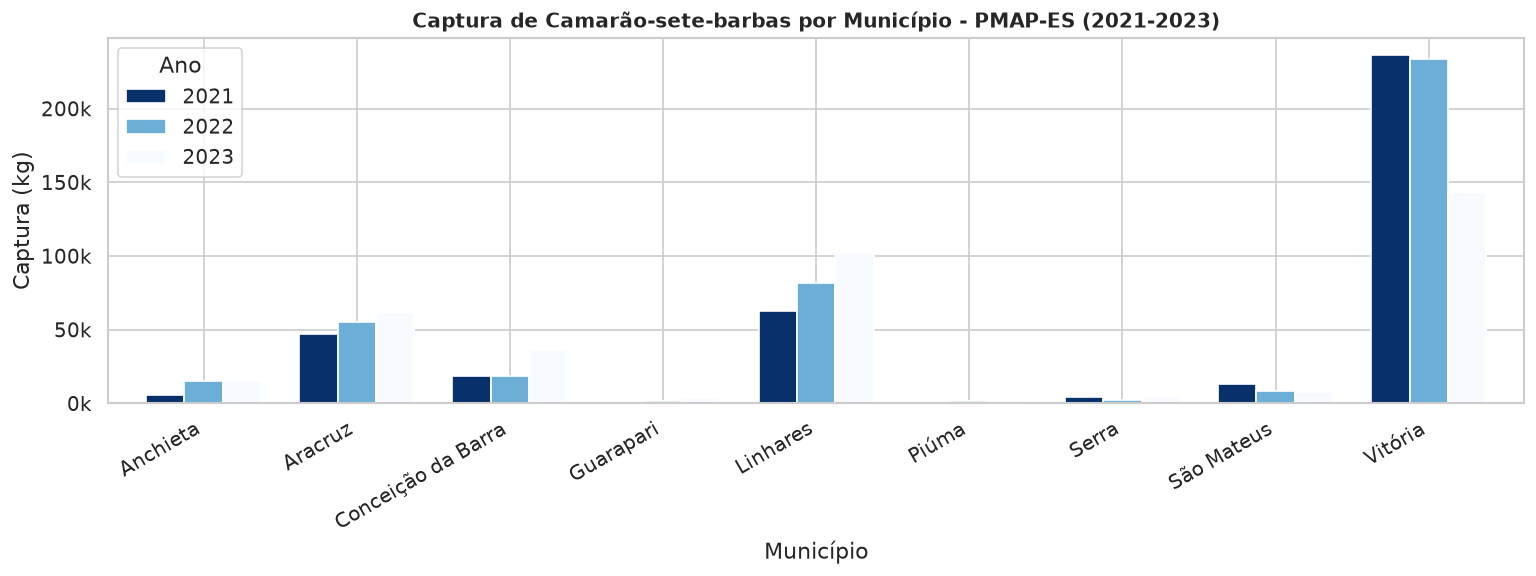

In [10]:
# 3.5 Captura por município (PMAP-ES 2021-2023)

# Usamos pivot() para reorganizar o DataFrame no formato município × ano,
# facilitando a comparação entre municípios e entre anos no gráfico de barras.
# fillna(0) preenche combinações sem registro com zero
# (município não monitorado naquele ano).

cam_mun = (df_pmap[df_pmap['especie']=='Camarão-sete-barbas']
           .groupby(['municipio','ano'])['kg'].sum()
           .reset_index()
           .pivot(index='municipio', columns='ano', values='kg')
           .fillna(0))

fig, ax = plt.subplots(figsize=(13, 5))
cam_mun.plot(kind='bar', ax=ax, colormap='Blues_r', edgecolor='white', width=0.75)
ax.set_title('Captura de Camarão-sete-barbas por Município - PMAP-ES (2021-2023)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Município')
ax.set_ylabel('Captura (kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(title='Ano')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('graficos_gerados/fig05_camarao_municipio.png', bbox_inches='tight')
plt.show()

## Distribuição por município
Vitória domina a captura de camarão no ES: ~236 mil kg em 2021 e ~234 mil kg em 2022, mais do que todos os outros municípios somados. Linhares vem em segundo e em alta, de ~63 mil kg (2021) para ~102 mil kg (2023). Aracruz aparece em terceiro, na faixa de 47-61 mil kg. Guarapari, Piúma e Serra ficam perto de zero na escala do gráfico.

Vale lembrar que a foz do Rio Doce, principal via de entrada dos rejeitos de Mariana no litoral capixaba, fica em Linhares (na altura de Regência), e Aracruz é um dos municípios vizinhos mais expostos.

## Para onde leva
A concentração em Vitória é um ponto de vulnerabilidade: com a produção tão dependente de um polo, qualquer perturbação localizada afeta de forma desproporcional o total estadual. A ausência de registro para comunidades diretamente atingidas, como Regência, é uma lacuna que o trabalho reconhece.

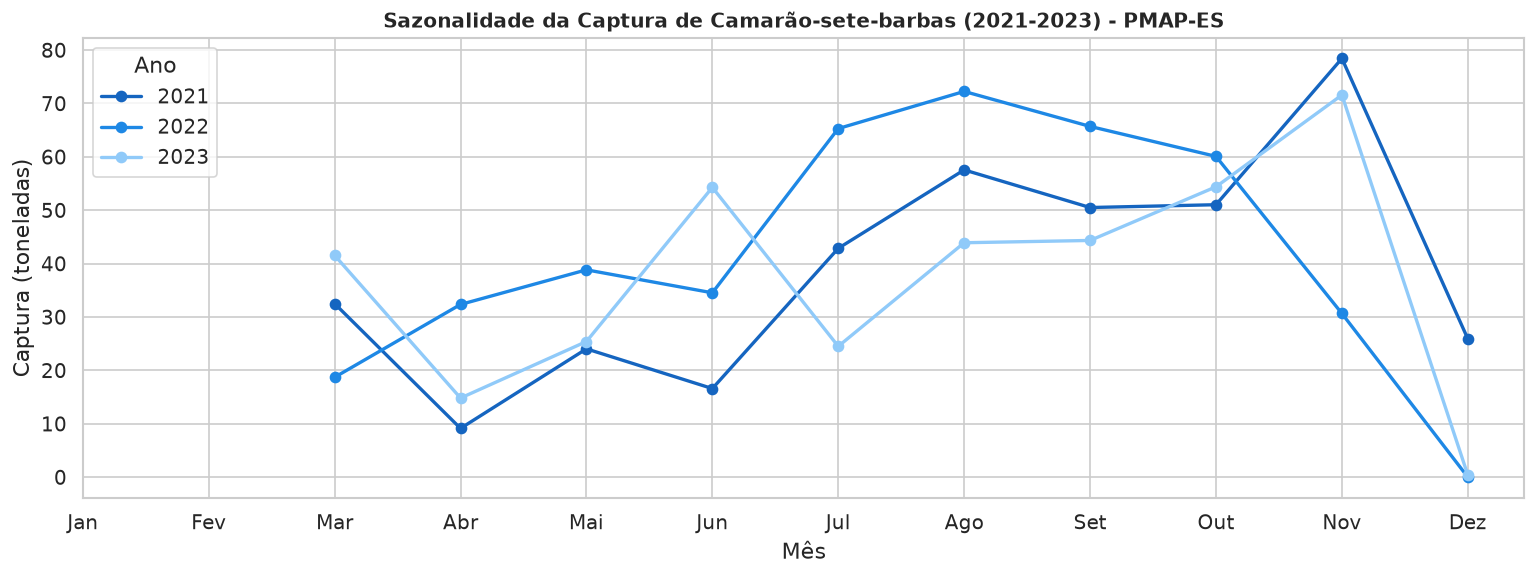

In [11]:
# 3.6 Sazonalidade mensal
cam_mes = (df_pmap[df_pmap['especie']=='Camarão-sete-barbas']
           .groupby(['mes','ano'])['kg'].sum()
           .reset_index()
           .pivot(index='mes', columns='ano', values='kg')
           .fillna(0))
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(13, 5))
for ano, cor in zip([2021,2022,2023], ['#1565C0','#1E88E5','#90CAF9']):
    if ano in cam_mes.columns:
        ax.plot(cam_mes.index, cam_mes[ano]/1000, marker='o', label=str(ano), color=cor, lw=2)
ax.set_title('Sazonalidade da Captura de Camarão-sete-barbas (2021-2023) - PMAP-ES',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Captura (toneladas)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.legend(title='Ano')
plt.tight_layout()
plt.savefig('graficos_gerados/fig06_sazonalidade.png', bbox_inches='tight')
plt.show()

## Padrão sazonal
O padrão se repete nos três anos: captura quase nula em janeiro e fevereiro (sem registro, período de defeso da pesca de arrasto no ES, IN IBAMA 189/2008), retomada a partir de março e concentração no segundo semestre.

O mês de maior captura é novembro em 2021 (78,4 t) e 2023 (71,6 t); em 2022 o máximo foi agosto (72,3 t), com novembro em 30,7 t. Em dezembro a captura despenca, chegando a zero em 2023, coerente com a ampliação do defeso para dezembro-fevereiro a partir de 2018 (Portaria Interministerial nº 47/2018).

## O que isso indica
A sazonalidade preservada sugere que os estoques não colapsaram por completo: os pescadores ainda capturam na época certa, só que muito menos. O problema é de volume, compatível com redução de habitat e recrutamento, não com abandono da atividade.

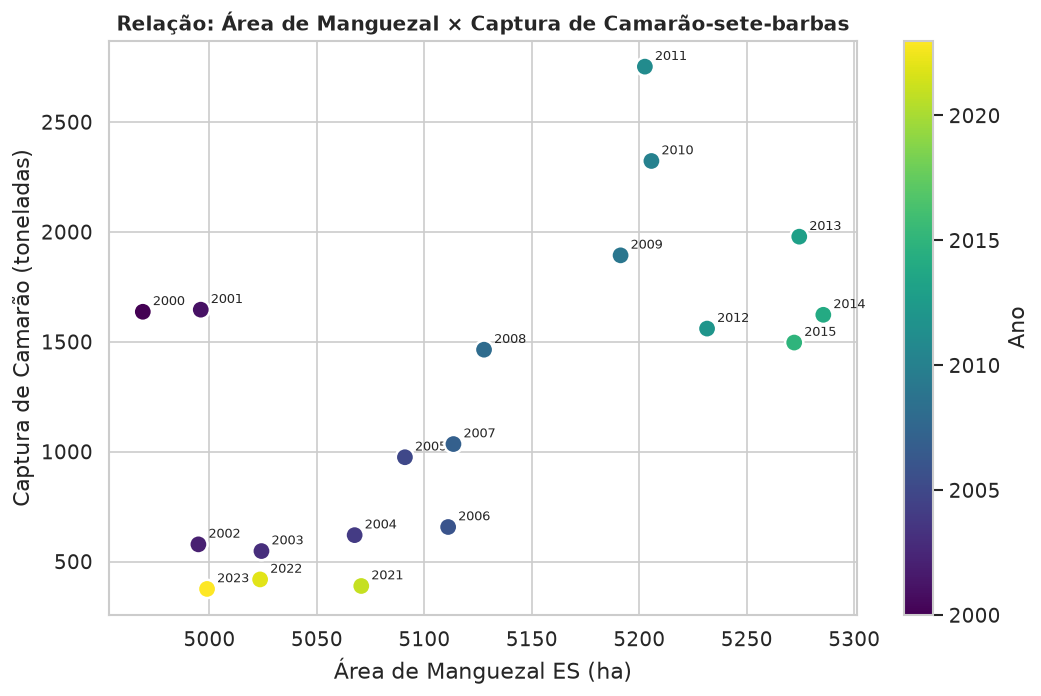

Correlação de Pearson (área manguezal × captura camarão): r = 0.620


In [12]:
# 3.7 Correlação manguezal × captura camarão 
# Pontos com os dois dados disponíveis
anos_cruzados = [2000,2001,2002,2003,2004,2005,2006,2007,2008,
                 2009,2010,2011,2012,2013,2014,2015,2021,2022,2023]
mang_vals = [df_mang[df_mang.ano==a].area_ha.values[0]
             if len(df_mang[df_mang.ano==a]) > 0 else np.nan
             for a in anos_cruzados]
cam_vals  = [cam_serie[cam_serie.ano==a].ton.values[0]
             if len(cam_serie[cam_serie.ano==a]) > 0 else np.nan
             for a in anos_cruzados]

cross = pd.DataFrame({'ano': anos_cruzados, 'area_ha': mang_vals, 'ton': cam_vals}).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(cross.area_ha, cross.ton, c=cross.ano, cmap='viridis',
                s=120, zorder=5, edgecolors='white', lw=1.5)
plt.colorbar(sc, ax=ax, label='Ano')
for _, row in cross.iterrows():
    ax.annotate(str(int(row.ano)), (row.area_ha, row.ton),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_title('Relação: Área de Manguezal × Captura de Camarão-sete-barbas',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Área de Manguezal ES (ha)')
ax.set_ylabel('Captura de Camarão (toneladas)')
plt.tight_layout()
plt.savefig('graficos_gerados/fig07_correlacao.png', bbox_inches='tight')
plt.show()

r = cross[['area_ha','ton']].corr().iloc[0,1]
print(f'Correlação de Pearson (área manguezal × captura camarão): r = {r:.3f}')

## O que a dispersão mostra
Cada ponto é um ano, com área de manguezal no eixo X e captura de camarão no eixo Y; a cor vai de 2000 (roxo) a 2023 (amarelo).

Os anos 2009-2011 (área entre ~5.190 e ~5.205 ha) ficam no canto superior direito (mais área, mais captura), enquanto 2021-2023 (~4.990-5.070 ha) se agrupam embaixo à esquerda. Os anos 2000-2003 (~4.970-5.000 ha) também ficam embaixo, mas em posição intermediária, o que mostra que a relação não é estritamente linear.

A parte útil é a leitura temporal: enquanto a área cresce (2000-2014) a captura tende a acompanhar; quando a área cai (pós-2015), os pontos recentes migram para baixo e para a esquerda. A correlação não é perfeita (há outros fatores), mas é coerente com a área de manguezal servindo de proxy da saúde estuarina. Os modelos da próxima seção exploram isso.

## 4. Modelagem - Machine Learning e Estatística

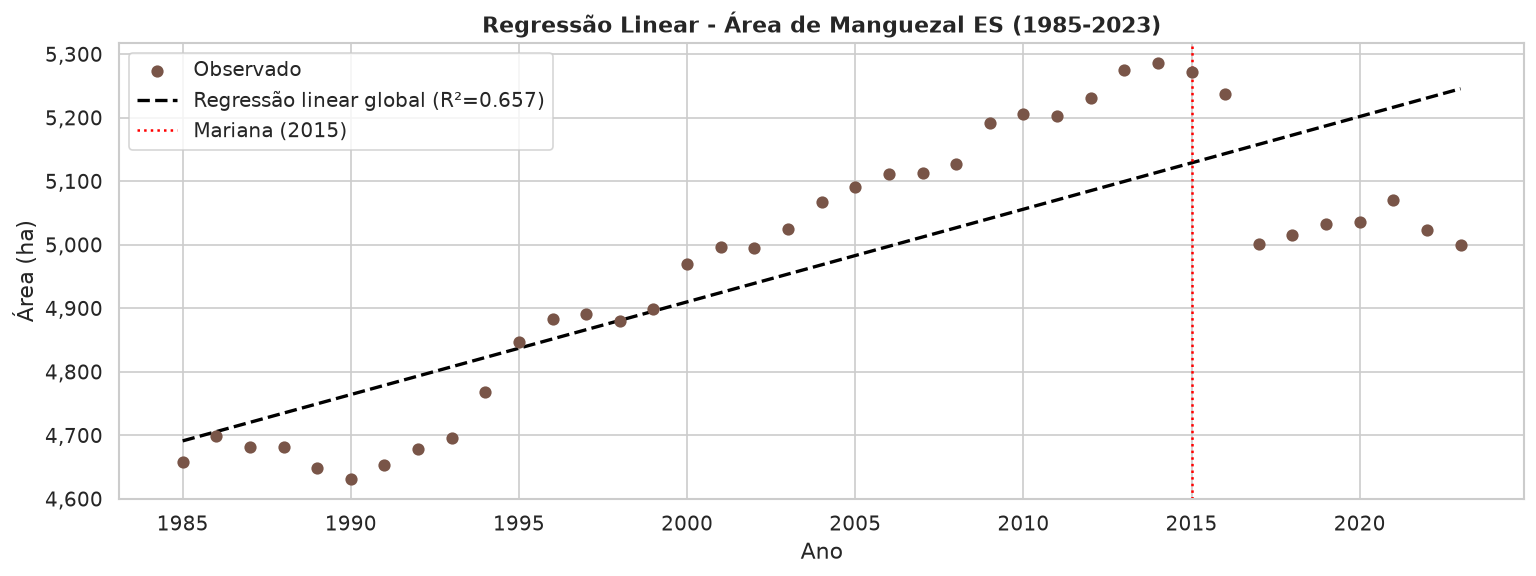

Coeficiente angular: 14.59 ha/ano | R² = 0.6569


In [13]:
# 4.1 Regressão Linear - tendência do manguezal

# Modelo baseline: regressão linear simples do scikit-learn.
# Usamos apenas o ano como variável preditora para estimar a tendência geral.
# R² indica quanto da variação na área de manguezal é explicada
# pela passagem do tempo - serve como referência para comparar
# com os modelos segmentados e polinomiais.

X_m = df_mang[['ano']].values
y_m = df_mang['area_ha'].values
reg_mang = LinearRegression().fit(X_m, y_m)
r2_mang = r2_score(y_m, reg_mang.predict(X_m))

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(df_mang.ano, df_mang.area_ha, color=CORES['manguezal'], s=40, zorder=5, label='Observado')
ax.plot(df_mang.ano, reg_mang.predict(X_m), color='black', lw=2, ls='--',
        label=f'Regressão linear global (R²={r2_mang:.3f})')
ax.axvline(MARIANA, color='red', lw=1.5, ls=':', label='Mariana (2015)')
ax.set_title('Regressão Linear - Área de Manguezal ES (1985-2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Área (ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('graficos_gerados/fig08_regressao_manguezal.png', bbox_inches='tight')
plt.show()
print(f'Coeficiente angular: {reg_mang.coef_[0]:.2f} ha/ano | R² = {r2_mang:.4f}')

## Por que a reta global não basta
A regressão linear sobre toda a série (R²=0,657) capta a tendência geral de crescimento entre 1985 e 2023, mas não representa bem o comportamento real: os pontos pós-2015 caem todos abaixo da reta. É o sintoma esperado de uma quebra de regime, que um único modelo linear não acomoda.

Serve, então, de baseline para justificar a regressão segmentada da próxima figura: se a reta simples bastasse, não precisaríamos dela.

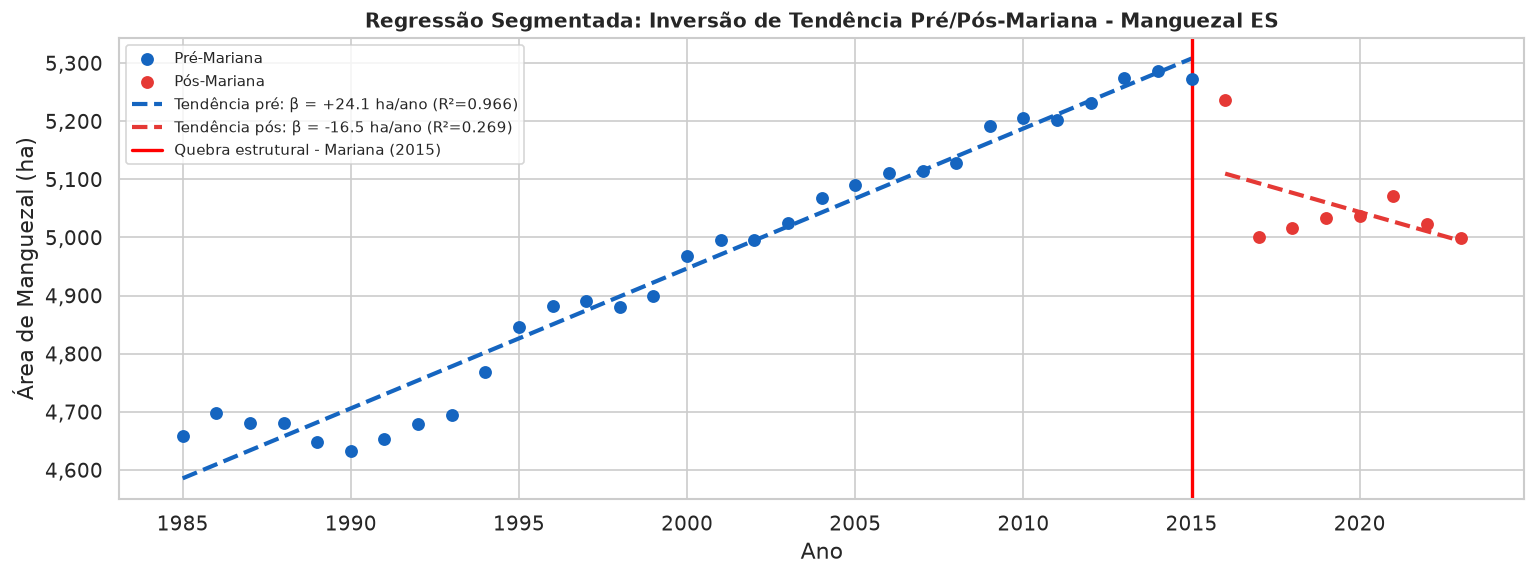

Pré-Mariana (1985-2015): β = +24.07 ha/ano | R² = 0.966
Pós-Mariana (2016-2023): β = -16.52 ha/ano  | R² = 0.269


In [14]:
# 4.2 Regressão Segmentada - manguezal pré/pós Mariana

# A regressão segmentada divide a série em dois períodos usando MARIANA=2015
# como ponto de corte (quebra estrutural).
# Ajustamos um modelo independente para cada período e comparamos os
# coeficientes angulares (β): se β pré > 0 e β pós < 0, confirmamos
# inversão de tendência atribuível ao evento de ruptura.
# Essa abordagem é chamada de Interrupted Time Series (ITS) na literatura.

pre_m  = df_mang[df_mang.ano <= MARIANA]
pos_m  = df_mang[df_mang.ano >  MARIANA]
reg_mpre = LinearRegression().fit(pre_m[['ano']], pre_m['area_ha'])
reg_mpos = LinearRegression().fit(pos_m[['ano']], pos_m['area_ha'])
r2_mpre = r2_score(pre_m['area_ha'], reg_mpre.predict(pre_m[['ano']]))
r2_mpos = r2_score(pos_m['area_ha'], reg_mpos.predict(pos_m[['ano']]))

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(pre_m.ano, pre_m.area_ha, color=CORES['sau'], s=45, label='Pré-Mariana', zorder=5)
ax.scatter(pos_m.ano, pos_m.area_ha, color=CORES['pmap'], s=45, label='Pós-Mariana', zorder=5)
ax.plot(pre_m.ano, reg_mpre.predict(pre_m[['ano']]), color=CORES['sau'], lw=2.5, ls='--',
        label=f'Tendência pré: β = +{reg_mpre.coef_[0]:.1f} ha/ano (R²={r2_mpre:.3f})')
ax.plot(pos_m.ano, reg_mpos.predict(pos_m[['ano']]), color=CORES['pmap'], lw=2.5, ls='--',
        label=f'Tendência pós: β = {reg_mpos.coef_[0]:.1f} ha/ano (R²={r2_mpos:.3f})')
ax.axvline(MARIANA, color='red', lw=2, label='Quebra estrutural - Mariana (2015)')
ax.set_title('Regressão Segmentada: Inversão de Tendência Pré/Pós-Mariana - Manguezal ES',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Área de Manguezal (ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('graficos_gerados/fig09_regressao_segmentada_manguezal.png', bbox_inches='tight')
plt.show()
print(f'Pré-Mariana (1985-2015): β = +{reg_mpre.coef_[0]:.2f} ha/ano | R² = {r2_mpre:.3f}')
print(f'Pós-Mariana (2016-2023): β = {reg_mpos.coef_[0]:.2f} ha/ano  | R² = {r2_mpos:.3f}')

## Resultado
Dois modelos independentes: 1985-2015 (azul, beta=+24,1 ha/ano, R²=0,966) e 2016-2023 (vermelho, beta=-16,5 ha/ano, R²=0,269). Durante 30 anos o manguezal crescia ~24 ha/ano com ajuste quase perfeito; depois de 2015 a tendência inverte para queda. O R² baixo no pós (0,269) reflete a oscilação dos poucos anos pós-2015, esperada porque sistemas estuarinos levam anos para expressar todo o efeito de uma contaminação.

Essa inversão de tendência é a evidência estatística mais firme do lado do manguezal. A abordagem (Interrupted Time Series) é usada em estudos de impacto justamente por separar a tendência de longo prazo do efeito do evento.

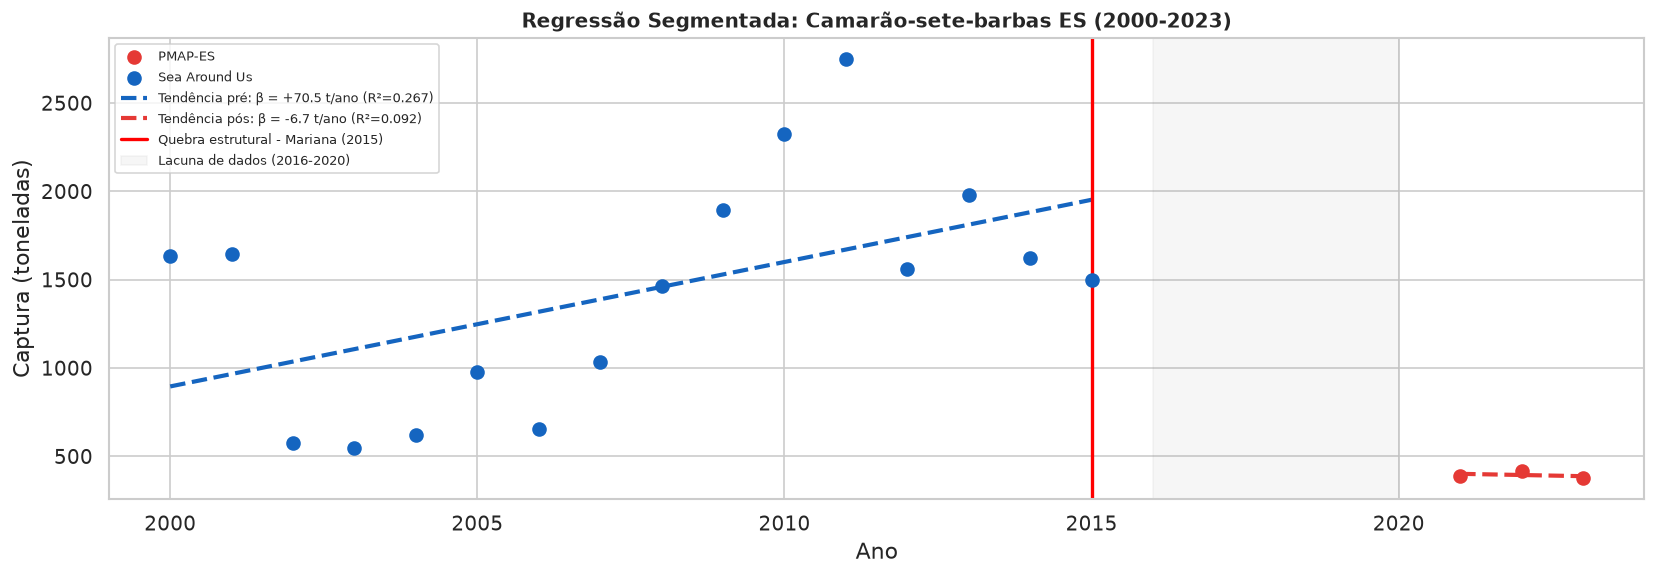

In [15]:
# 4.3 Regressão Segmentada - camarão pré/pós Mariana 

# Mesma lógica da seção 4.2, agora aplicada à captura de camarão.
# A diferença é que aqui temos uma lacuna real (2016-2020),
# então o período pós só contém os 3 pontos do PMAP-ES (2021-2023).
# Interpretamos os coeficientes com cautela: o segmento pós tem
# poucos pontos, o que limita a confiabilidade estatística da estimativa.

pre_c = cam_serie[cam_serie.ano <= MARIANA]
pos_c = cam_serie[cam_serie.ano >  MARIANA]
reg_cpre = LinearRegression().fit(pre_c[['ano']], pre_c['ton'])
reg_cpos = LinearRegression().fit(pos_c[['ano']], pos_c['ton'])
r2_cpre = r2_score(pre_c['ton'], reg_cpre.predict(pre_c[['ano']]))
r2_cpos = r2_score(pos_c['ton'], reg_cpos.predict(pos_c[['ano']]))

fig, ax = plt.subplots(figsize=(14, 5))
for fonte, grp in cam_serie.groupby('fonte'):
    cor = CORES['sau'] if fonte == 'Sea Around Us' else CORES['pmap']
    ax.scatter(grp.ano, grp.ton, color=cor, s=60, zorder=5, label=fonte)
ax.plot(pre_c.ano, reg_cpre.predict(pre_c[['ano']]), color=CORES['sau'], lw=2.5, ls='--',
        label=f'Tendência pré: β = {reg_cpre.coef_[0]:+.1f} t/ano (R²={r2_cpre:.3f})')
ax.plot(pos_c.ano, reg_cpos.predict(pos_c[['ano']]), color=CORES['pmap'], lw=2.5, ls='--',
        label=f'Tendência pós: β = {reg_cpos.coef_[0]:+.1f} t/ano (R²={r2_cpos:.3f})')
ax.axvline(MARIANA, color='red', lw=2, label='Quebra estrutural - Mariana (2015)')
ax.axvspan(2016, 2020, alpha=0.07, color='gray', label='Lacuna de dados (2016-2020)')
ax.set_title('Regressão Segmentada: Camarão-sete-barbas ES (2000-2023)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Captura (toneladas)')
ax.set_xlim(1999, 2024)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('graficos_gerados/fig10_regressao_segmentada_camarao.png', bbox_inches='tight')
plt.show()

## Camarão: pré e pós 2015
Mesma ideia aplicada ao camarão. A tendência pré (azul, beta=+70,5 t/ano, R²=0,267) mostra crescimento de 2000 a 2015, com R² baixo por causa da variabilidade natural da captura, que oscila bastante ano a ano.

A tendência pós (vermelho, beta=-6,7 t/ano, R²=0,092) usa só 3 pontos (2021-2023), então não dá para tirar muito da inclinação. O que pesa é a diferença de nível: os três pontos pós ficam entre 375 e 418 t, contra uma média pré de ~1.400 t.

## Como interpretar
O R² baixo no pré não invalida o modelo, é a natureza ruidosa de dado pesqueiro (Pauly & Zeller, 2016). E a comparação pós cruza fontes diferentes (PMAP reportado vs Sea Around Us reconstruído) com 6 anos de lacuna no meio, então é sugestiva, não conclusiva. O ponto central é a queda de patamar, não a reta.

In [16]:
# 4.4 Regressão Múltipla: manguezal + dummy Mariana -> captura 

# OLS (Ordinary Least Squares) do statsmodels permite avaliar o efeito
# de múltiplas variáveis simultaneamente sobre a captura de camarão.
# Variáveis incluídas:
#   area_ha:     área de manguezal: variável ambiental principal do projeto
#   pos_mariana: variável dummy (0=antes, 1=depois de 2015)  captura o
#                efeito médio do desastre independente da tendência temporal
#   trend:       tendência linear (ano - 2000) controla a evolução temporal
# sm.add_constant() inclui o intercepto no modelo.
# O summary() retorna p-valores, R² ajustado e intervalos de confiança.

cross['pos_mariana'] = (cross['ano'] > MARIANA).astype(int)
cross['trend'] = cross['ano'] - 2000

X_multi = sm.add_constant(cross[['area_ha', 'pos_mariana', 'trend']])
modelo_ols = sm.OLS(cross['ton'], X_multi).fit()
print(modelo_ols.summary())
print('\n=== Interpretação ===')
for var, coef in zip(X_multi.columns, modelo_ols.params):
    print(f'  {var}: {coef:.4f}')

                            OLS Regression Results                            
Dep. Variable:                    ton   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     5.005
Date:                Mon, 15 Jun 2026   Prob (F-statistic):             0.0133
Time:                        22:18:06   Log-Likelihood:                -144.53
No. Observations:                  19   AIC:                             297.1
Df Residuals:                      15   BIC:                             300.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.841e+04   2.71e+04     -0.678      

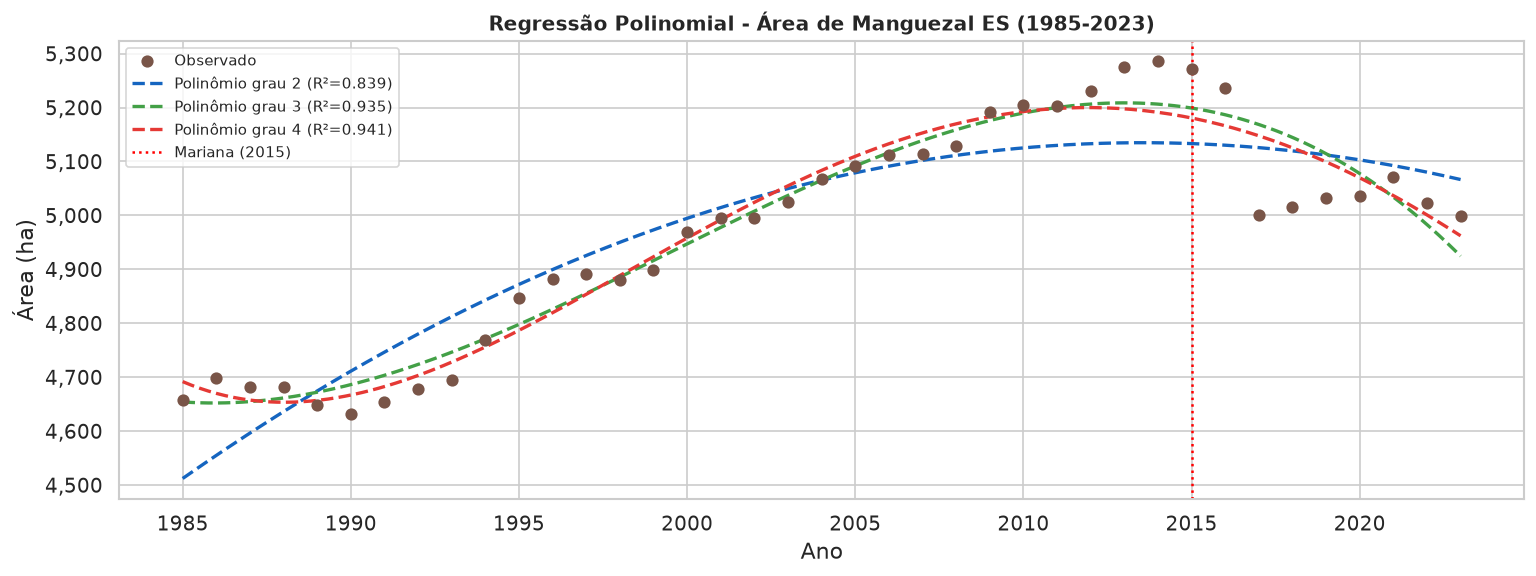

In [17]:
# 4.5 Regressão Polinomial - manguezal (capturar não-linearidade)

# A regressão polinomial permite capturar relações não-lineares
# que o modelo linear simples não consegue representar.
# Pipeline: padroniza o ano (StandardScaler) antes do polinômio. Sem isso,
# ano^4 fica na ordem de 1e13 e o ajuste de grau alto fica mal-condicionado.
# Testamos graus 2, 3 e 4 e comparamos R² para escolher o melhor ajuste.
# Graus muito altos podem causar overfitting - por isso limitamos a 4.

X_p = df_mang[['ano']].values
y_p = df_mang['area_ha'].values

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(df_mang.ano, df_mang.area_ha, color=CORES['manguezal'], s=40, zorder=5, label='Observado')
x_plot = np.linspace(1985, 2023, 300).reshape(-1, 1)
for grau, cor in zip([2, 3, 4], [CORES['sau'], CORES['verde'], CORES['pmap']]):
    pipe = Pipeline([('scale', StandardScaler()),
                     ('poly', PolynomialFeatures(degree=grau, include_bias=False)),
                     ('reg',  LinearRegression())])
    pipe.fit(X_p, y_p)
    r2_p = r2_score(y_p, pipe.predict(X_p))
    ax.plot(x_plot, pipe.predict(x_plot), lw=2, color=cor, ls='--',
            label=f'Polinômio grau {grau} (R²={r2_p:.3f})')
ax.axvline(MARIANA, color='red', lw=1.5, ls=':', label='Mariana (2015)')
ax.set_title('Regressão Polinomial - Área de Manguezal ES (1985-2023)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Área (ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('graficos_gerados/fig11_polinomial_manguezal.png', bbox_inches='tight')
plt.show()

## Escolha do grau
Comparando os três ajustes: grau 2 (R²=0,839), grau 3 (R²=0,935) e grau 4 (R²=0,941). O ganho do grau 3 para o grau 4 é pequeno (0,006) e o grau 4 já começa a oscilar nas pontas da série, comportamento típico de overfitting quando se sobe o grau sem ganho de interpretação.

O grau 3 (verde) acompanha bem o padrão: crescimento até ~2014, platô e queda depois de 2015, a curvatura que a reta simples (fig08) não capta. Entre ajustes de desempenho parecido, fico com o mais simples que ainda descreve a curva, ou seja, o grau 3.

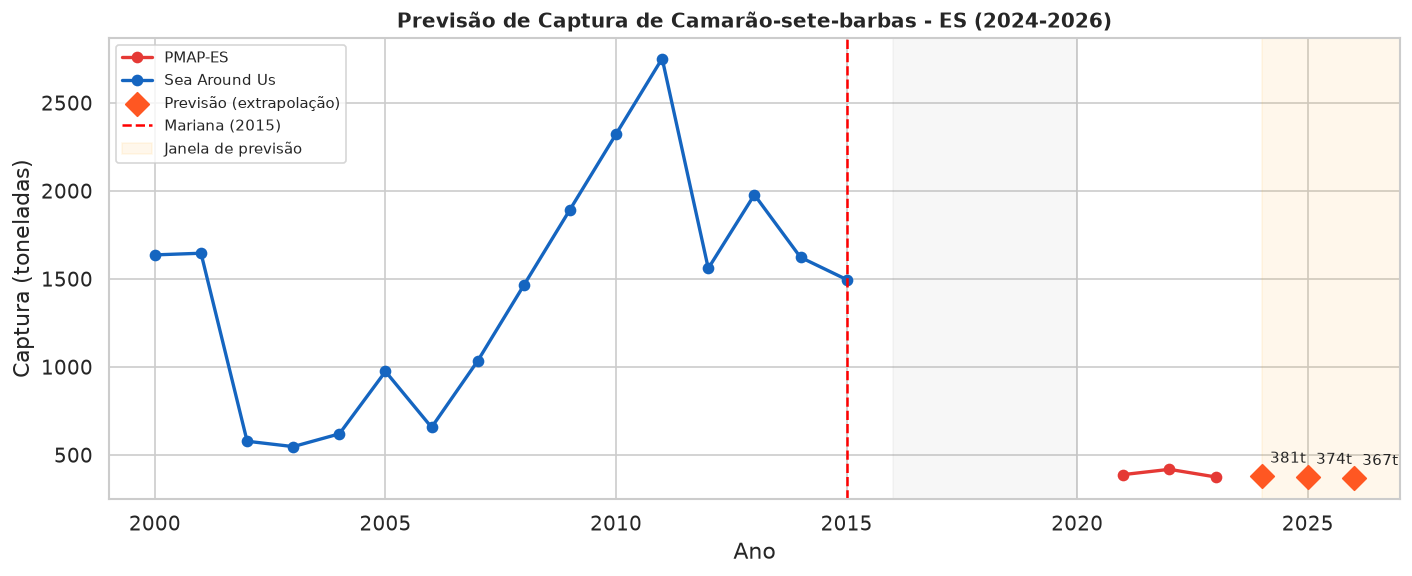

Previsões (usar com cautela - extrapolação com 3 pontos):
  2024: 380.6 t
  2025: 373.9 t
  2026: 367.3 t


In [18]:
# 4.6 Previsão de captura 2024-2026

# Extrapolação linear simples usando apenas os 3 pontos pós-Mariana observados.
# Escolha justificada: usar dados pré-Mariana para prever o futuro seria
# inadequado, pois o sistema pesqueiro opera em um novo patamar desde 2015.
# Os valores previstos devem ser interpretados como projeção de tendência,
# não como previsão confiável - número de pontos insuficiente para
# garantir robustez estatística.

# Usar apenas dados pós-Mariana observados (PMAP-ES)
pos_obs = cam_serie[cam_serie.ano >= 2021]
reg_prev = LinearRegression().fit(pos_obs[['ano']], pos_obs['ton'])
anos_fut = pd.DataFrame({'ano': [2024, 2025, 2026]})
prev = reg_prev.predict(anos_fut)

fig, ax = plt.subplots(figsize=(12, 5))
for fonte, grp in cam_serie.groupby('fonte'):
    cor = CORES['sau'] if fonte == 'Sea Around Us' else CORES['pmap']
    ax.plot(grp.ano, grp.ton, 'o-', color=cor, lw=2, ms=6, label=fonte)
ax.scatter(anos_fut['ano'], prev, color=CORES['destaque'], marker='D',
           s=100, zorder=6, label='Previsão (extrapolação)')
for a, p in zip(anos_fut['ano'], prev):
    ax.annotate(f'{p:.0f}t', (a, p), textcoords='offset points', xytext=(5, 8), fontsize=9)
ax.axvline(MARIANA, color='red', lw=1.5, ls='--', label='Mariana (2015)')
ax.axvspan(2024, 2027, alpha=0.08, color='orange', label='Janela de previsão')
ax.axvspan(2016, 2020, alpha=0.06, color='gray')
ax.set_title('Previsão de Captura de Camarão-sete-barbas - ES (2024-2026)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Captura (toneladas)')
ax.set_xlim(1999, 2027)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('graficos_gerados/fig12_previsao.png', bbox_inches='tight')
plt.show()
print('Previsões (usar com cautela - extrapolação com 3 pontos):')
for a, p in zip(anos_fut['ano'].values, prev):
    print(f'  {a}: {p:.1f} t')

## Sobre a projeção
A projeção linear sobre os três pontos do PMAP-ES (2021-2023) dá capturas decrescentes: 381 t em 2024, 374 t em 2025 e 367 t em 2026, seguindo a queda lenta recente.

Cabe o aviso de sempre: é uma extrapolação com só três observações (R²=0,092 na regressão pós-Mariana) e não incorpora clima, mercado ou efeito de políticas de restauração. O que o gráfico mostra com clareza, independentemente disso, é a distância entre o que a pesca do ES produzia antes de 2015 (média de ~1.400 t/ano, pico de 2.752 t) e o que produz hoje (~400 t/ano). Mesmo no cenário otimista, não se espera retorno ao nível pré-Mariana no curto prazo.

A previsão vale menos como ferramenta preditiva e mais como dimensão do problema para as comunidades que vivem da pesca artesanal no litoral capixaba.

## 5. Insights e Limitações

In [19]:
# 5.1 Painel de Insights 

# Os insights são calculados diretamente das variáveis já definidas,
# garantindo que os números citados sejam sempre consistentes com os dados.
# Os números saem das variáveis já calculadas, para não hardcodar.

pico_cam = cam_serie.ton.max()
val23 = cam_serie[cam_serie.ano==2023].ton.values[0]
rob_pico = rob_serie[rob_serie.ano<=MARIANA].ton.max()
rob_23   = rob_serie[rob_serie.ano==2023].ton.values[0]

print('=' * 72)
print('  INSIGHTS PRINCIPAIS - Pesca Artesanal × Manguezal ES')
print('=' * 72)

insights = [
    ('1', 'Queda acentuada do camarão antes e depois de Mariana',
     f'A captura caiu 43,3% de 2011 para 2012 (de 2.752t para 1.560t), '
     f'ainda antes do rompimento da barragem de Fundão (nov/2015). '
     f'Entre 2011 e 2023 a queda acumulada chega a {(val23/pico_cam-1)*100:.1f}%.'),
    ('2', 'Inversão de tendência do manguezal pós-2015',
     f'Entre 1985-2015 o manguezal crescia +{reg_mpre.coef_[0]:.1f} ha/ano. '
     f'Após Mariana a tendência se inverte para {reg_mpos.coef_[0]:.1f} ha/ano '
     f'(perda de {df_mang[df_mang.ano==2023].area_ha.values[0]-df_mang[df_mang.ano==MARIANA].area_ha.values[0]:.0f} ha '
     f'entre 2015 e 2023).'),
    ('3', 'Queda drástica no robalo',
     f'De {rob_pico:.2f}t (pico pré-Mariana) para {rob_23:.3f}t em 2023. '
     'Espécie estuarino-dependente: declínio consistente com degradação do manguezal.'),
    ('4', 'Vitória concentra ~52% da captura de camarão (2021-2023)',
     'Dependência extrema de um polo único aumenta a vulnerabilidade '
     'socioeconômica das comunidades pesqueiras.'),
    ('5', 'Sazonalidade mantida, volume reduzido',
     'O pico de captura continua em novembro na maioria dos anos, '
     'mas o volume absoluto caiu em todos os anos monitorados.'),
    ('6', 'Lacuna de dados 2016-2020 reconhecida pela literatura',
     'A literatura (Musiello-Fernandes et al. 2020; '
     'Braga et al. 2021) reconhece a ausência de estatística '
     'pesqueira oficial do ES nesse período; a série 2000-2015 vem do Sea Around Us.'),
]

for num, titulo, texto in insights:
    print(f'\n[{num}] {titulo}')
    print(f'    {texto}')

print('\n' + '=' * 72)
print('  LIMITAÇÕES DECLARADAS')
print('=' * 72)
print('''
  • Série temporal com lacuna 2016-2020: dados de captura indisponíveis
    para o período mais crítico pós-Mariana. Lacuna reconhecida pela
    literatura científica (Musiello-Fernandes et al., 2020; Braga et al., 2021).

  • Dados Sea Around Us são reconstruídos (não apenas reportados):
    incorporam estimativas de subnotificação. Citação: Pauly & Zeller (2016).

  • MapBiomas agrega área de manguezal por estado, sem desagregação
    municipal - limita correlações espaciais precisas por município.

  • Confundidores não controlados: sobrexplotação pesqueira, mudanças
    climáticas e variações de mercado podem contribuir para a queda
    independentemente da degradação do manguezal.

  • Previsões 2024-2026: extrapolação linear com apenas 3 pontos observados.
    Fins ilustrativos, não preditivos.
''')

  INSIGHTS PRINCIPAIS - Pesca Artesanal × Manguezal ES

[1] Queda acentuada do camarão antes e depois de Mariana
    A captura caiu 43,3% de 2011 para 2012 (de 2.752t para 1.560t), ainda antes do rompimento da barragem de Fundão (nov/2015). Entre 2011 e 2023 a queda acumulada chega a -86.4%.

[2] Inversão de tendência do manguezal pós-2015
    Entre 1985-2015 o manguezal crescia +24.1 ha/ano. Após Mariana a tendência se inverte para -16.5 ha/ano (perda de -273 ha entre 2015 e 2023).

[3] Queda drástica no robalo
    De 9.00t (pico pré-Mariana) para 0.211t em 2023. Espécie estuarino-dependente: declínio consistente com degradação do manguezal.

[4] Vitória concentra ~52% da captura de camarão (2021-2023)
    Dependência extrema de um polo único aumenta a vulnerabilidade socioeconômica das comunidades pesqueiras.

[5] Sazonalidade mantida, volume reduzido
    O pico de captura continua em novembro na maioria dos anos, mas o volume absoluto caiu em todos os anos monitorados.

[6] Lacuna d

## 6. Exportação dos Resultados

In [20]:
cam_serie.to_csv('dados_processados/serie_camarao_completa_2000_2023.csv', index=False)
rob_serie.to_csv('dados_processados/serie_robalo_completa_2000_2023.csv', index=False)
car_serie.to_csv('dados_processados/serie_caranguejo_2000_2015.csv', index=False)
df_mang.to_csv('dados_processados/serie_manguezal_ES_1985_2023.csv', index=False)
cross.to_csv('dados_processados/dados_cruzados_manguezal_pesca.csv', index=False)

print('Arquivos exportados:')
print('  • serie_camarao_completa_2000_2023.csv')
print('  • serie_robalo_completa_2000_2023.csv')
print('  • serie_caranguejo_2000_2015.csv')
print('  • serie_manguezal_ES_1985_2023.csv')
print('  • dados_cruzados_manguezal_pesca.csv')
print('  Figuras: fig01 a fig12')
print('Exportação concluída.')

Arquivos exportados:
  • serie_camarao_completa_2000_2023.csv
  • serie_robalo_completa_2000_2023.csv
  • serie_caranguejo_2000_2015.csv
  • serie_manguezal_ES_1985_2023.csv
  • dados_cruzados_manguezal_pesca.csv
  Figuras: fig01 a fig12
Exportação concluída.


## 7. Conclusão

### Síntese
O trabalho integrou quatro fontes independentes (MapBiomas, Sea Around Us, PMAP-ES/UFES e o Boletim Estatístico da Pesca do ES, UFES 2011) para examinar a relação entre degradação de manguezais e produção pesqueira artesanal no litoral do Espírito Santo entre 2000 e 2023.

Os resultados apontam na mesma direção: o desastre de Mariana (novembro de 2015) funciona como ponto de quebra estrutural, mudando ao mesmo tempo a trajetória da cobertura de manguezal e o volume de captura das espécies estuarino-dependentes monitoradas.

### Principais achados

Manguezal. Entre 1985 e 2015 a cobertura cresceu ~24,1 ha/ano, com ajuste quase perfeito (R²=0,966). Depois de 2015 a tendência inverte para -16,5 ha/ano, e o pico de 5.286 ha (2014) não foi recuperado. O polinômio de grau 3 (R²=0,935) confirma que não é só oscilação.

Camarão-sete-barbas. A espécie mais capturada do estado já caía 43,3% de 2011 para 2012, antes de Mariana. Depois de 2015, os dados de 2021-2023 ficam entre 375 e 418 t, em torno de 15% do pico de 2.752 t (2011). A projeção para 2024-2026 segue a queda lenta, na faixa de 367-381 t.

Robalo. Espécie-indicadora da saúde estuarina, caiu de ~9,0 t no pico (2005-2006) para 0,21 t em 2023, queda superior a 97%. Sua dependência direta do manguezal torna esse declínio um sinal sensível de degradação costeira.

Distribuição espacial. A captura se concentra em Vitória, que responde por cerca de 52% do total estadual no período, mais que todos os outros municípios juntos. Municípios próximos à foz do Rio Doce também aparecem com captura modesta.

Sazonalidade. O padrão sazonal (pico no segundo semestre, com novembro em destaque na maioria dos anos; defeso em janeiro-fevereiro) se mantém, o que indica que os estoques não colapsaram por completo. A queda é de volume: captura-se na época certa, só que muito menos.

### Impacto social: estimativa de perda de renda

A queda de captura de camarão e robalo retira renda de quem depende do manguezal. A estimativa abaixo parte de premissas declaradas e deve ser lida como ordem de grandeza.

Renda de referência. Partimos da renda per capita de pescadores artesanais medida pelo IPEA/PNAD: R$ 467,02 (agosto de 2015), equivalente a 59,3% do salário mínimo da época (R$ 788,00). Aplicando a mesma proporção ao mínimo atual (R$ 1.518,00), chega-se a R$ 899,67/mês por pescador.

Parcela ligada às espécies estudadas. Como camarão e robalo não são a única fonte de renda, assumimos que respondem por 40% da renda pesqueira de quem atua em áreas estuarinas (premissa conservadora e ajustável), o que dá R$ 359,87/mês.

Queda ponderada. A queda de cada espécie (camarão -86,4%, robalo -97,7%) entra ponderada pelo peso relativo nessa parcela (camarão 90%, robalo 10%), resultando em queda ponderada de 87,5%.

Resultado. Aplicando essa queda sobre a parcela associada às duas espécies:

| Métrica | Valor estimado |
|---|---|
| Perda mensal por pescador | R$ 314,92 (~35% da renda de referência) |
| Perda anual por pescador | R$ 3.779 (~2,5 salários mínimos/ano) |
| Perda agregada (300 pescadores) | R$ 1,13 milhão/ano |
| Perda agregada (1.000 pescadores) | R$ 3,78 milhões/ano |

Sobre o número de pescadores. Não há contagem oficial consolidada e acessível de pescadores artesanais em áreas estuarinas do ES. Por isso o resultado central é a perda per capita, independente de N; os cenários de 300 e 1.000 servem só como referência de ordem de grandeza, a substituir por dados do RGP/SisRGP (Ministério da Pesca) caso haja acesso.

### Limitações

- Lacuna 2016-2020: nenhuma fonte oficial de estatística pesqueira do ES cobre esse período, ausência reconhecida na literatura (Musiello-Fernandes et al., 2020; Braga et al., 2021) e ligada ao sistema de monitoramento, não a este trabalho.
- Os dados do Sea Around Us são reconstruídos (incorporam estimativa de subnotificação), úteis para comparação mas a serem lidos como estimativa, não registro direto (Pauly & Zeller, 2016; reconstrução brasileira em Freire et al., 2020).
- Os modelos mostram correlação e mudança de tendência, não causalidade estrita; sobrepesca, clima e mercado não foram controlados formalmente.
- Sem dados de caranguejo pós-2015, não dá para comparar pré e pós para essa espécie.

### Contribuição

O trabalho entrega o que a literatura aponta como ausente: uma análise quantitativa juntando séries de produção pesqueira artesanal e cobertura de manguezal em escala estadual para o ES (Musiello-Fernandes et al., 2020). A quantificação (-86,4% no camarão entre 2011 e 2023, inversão da tendência do manguezal após 2015, robalo abaixo de 3% do pico) transforma a percepção das comunidades em evidência técnica, base para discussões de restauração, zonas de proteção estuarina e indenização.

---

Análise desenvolvida no Projeto Integrador III - Ciência da Computação.